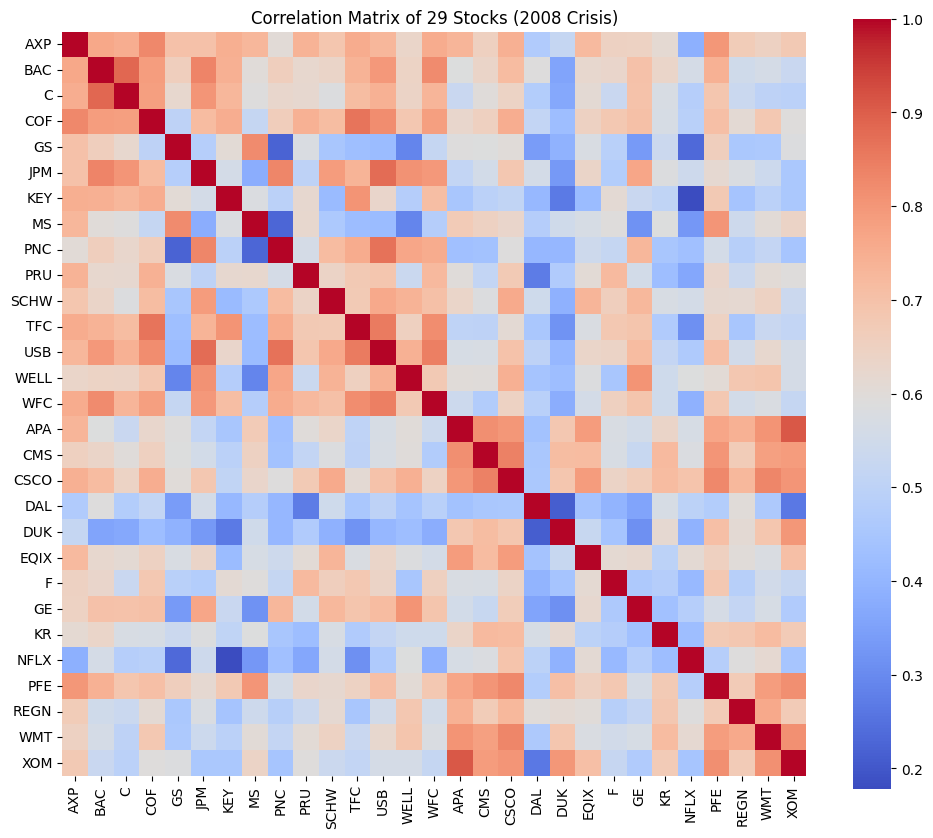

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list

# -----------------------------------------------
# Load CSV from absolute path
# -----------------------------------------------
csv_path = r"C:\Users\Shashwat\Desktop\team A TASKS _SHASHWAT\gwp3\combined_data_2008Q4.csv"
data = pd.read_csv(csv_path, index_col='Date', parse_dates=True)

# -----------------------------------------------
# Compute daily log returns
# -----------------------------------------------
daily_returns = np.log(data / data.shift(1)).dropna()

# -----------------------------------------------
# Plot raw correlation heatmap
# -----------------------------------------------
corr_matrix = daily_returns.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', square=True)
plt.title("Correlation Matrix of 29 Stocks (2008 Crisis)")
plt.show()



In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

# Distance metrics & linkage methods
distance_metrics = ['euclidean', 'cityblock', 'cosine', 'correlation']
linkage_methods = ['single', 'complete', 'average', 'ward']

# Store clustering results
cluster_results = {}

for metric in distance_metrics:
    for method in linkage_methods:
        if method == 'ward' and metric != 'euclidean':
            continue  # ward only works with Euclidean
        try:
            dist_matrix = pdist(daily_returns.T, metric=metric)
            linkage_matrix = linkage(dist_matrix, method=method)
            clusters = fcluster(linkage_matrix, t=5, criterion='maxclust')  # e.g., 5 clusters
            cluster_results[(metric, method)] = clusters
        except Exception as e:
            print(f"Failed for ({metric}, {method}): {e}")


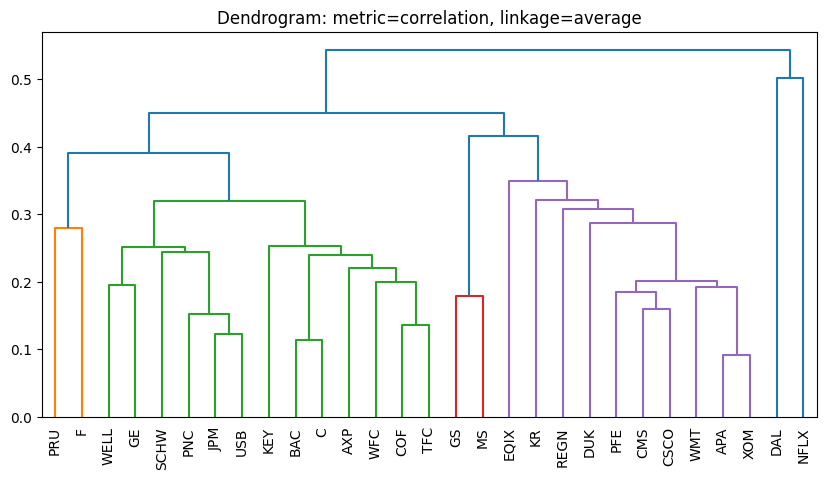

In [ ]:
# Helper function to plot dendrogram
def plot_dendrogram(metric, method):
    dist_matrix = pdist(daily_returns.T, metric=metric)
    linkage_matrix = linkage(dist_matrix, method=method)
    plt.figure(figsize=(10, 5))
    dendrogram(linkage_matrix, labels=daily_returns.columns, leaf_rotation=90)
    plt.title(f"Dendrogram: metric={metric}, linkage={method}")
    plt.show()

# Example
plot_dendrogram('correlation', 'average')


In [ ]:
from scipy.cluster.hierarchy import cophenet
from scipy.spatial.distance import squareform

for (metric, method), clusters in cluster_results.items():
    dist_matrix = pdist(daily_returns.T, metric=metric)
    Z = linkage(dist_matrix, method=method)
    coph_corr, _ = cophenet(Z, dist_matrix)
    print(f"Metric: {metric}, Linkage: {method}, Cophenetic Corr: {coph_corr:.3f}")


Metric: euclidean, Linkage: single, Cophenetic Corr: 0.931
Metric: euclidean, Linkage: complete, Cophenetic Corr: 0.733
Metric: euclidean, Linkage: average, Cophenetic Corr: 0.946
Metric: euclidean, Linkage: ward, Cophenetic Corr: 0.710
Metric: cityblock, Linkage: single, Cophenetic Corr: 0.889
Metric: cityblock, Linkage: complete, Cophenetic Corr: 0.796
Metric: cityblock, Linkage: average, Cophenetic Corr: 0.920
Metric: cosine, Linkage: single, Cophenetic Corr: 0.490
Metric: cosine, Linkage: complete, Cophenetic Corr: 0.640
Metric: cosine, Linkage: average, Cophenetic Corr: 0.718
Metric: correlation, Linkage: single, Cophenetic Corr: 0.484
Metric: correlation, Linkage: complete, Cophenetic Corr: 0.639
Metric: correlation, Linkage: average, Cophenetic Corr: 0.719


In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Transpose returns so that rows = stocks, cols = features (time)
X = daily_returns.T
X_scaled = StandardScaler().fit_transform(X)

# Optional: reduce dimensions for KMeans stability
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

# Fit KMeans
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca)


In [ ]:
from sklearn.metrics import adjusted_rand_score

# Choose your best hierarchical clustering
best_method = max(cluster_results.items(), key=lambda kv: cophenet(linkage(pdist(daily_returns.T, metric=kv[0][0]), method=kv[0][1]), pdist(daily_returns.T, metric=kv[0][0]))[0])
best_labels = best_method[1]

# ARI
ari_score = adjusted_rand_score(best_labels, kmeans_labels)
print(f"Adjusted Rand Index (ARI) between Hierarchical and KMeans: {ari_score:.3f}")


Adjusted Rand Index (ARI) between Hierarchical and KMeans: 0.187


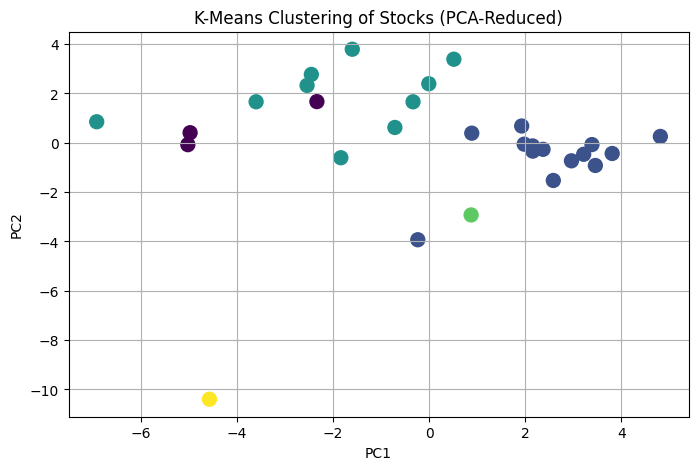

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', s=100)
plt.title("K-Means Clustering of Stocks (PCA-Reduced)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


In [ ]:
# -----------------------------------------------
# Cophenetic Correlation for Hierarchical
# -----------------------------------------------
from sklearn.metrics import silhouette_score
ccc_records = []

for (metric, method), clusters in cluster_results.items():
    dist_matrix = pdist(daily_returns.T, metric=metric)
    Z = linkage(dist_matrix, method=method)
    coph_corr, _ = cophenet(Z, dist_matrix)
    ccc_records.append({
        "Clustering Method": "Hierarchical",
        "Distance Metric": metric,
        "Linkage": method,
        "Cophenetic Corr": coph_corr,
        "ARI vs KMeans": adjusted_rand_score(clusters, kmeans_labels)
    })

ccc_df = pd.DataFrame(ccc_records)

# -----------------------------------------------
# KMeans: Inertia & Silhouette
# -----------------------------------------------
kmeans_inertia = kmeans.inertia_
sil_score = silhouette_score(X_pca, kmeans_labels)

# Append KMeans metrics
ccc_df = pd.concat([
    ccc_df,
    pd.DataFrame([{
        "Clustering Method": "KMeans",
        "Distance Metric": "euclidean (PCA)",
        "Linkage": "-",
        "Cophenetic Corr": None,
        "ARI vs KMeans": None,
        "Silhouette Score": sil_score,
        "Inertia": kmeans_inertia
    }])
], ignore_index=True)

# -----------------------------------------------
# Final Formatting
# -----------------------------------------------
ccc_df = ccc_df[[
    "Clustering Method", "Distance Metric", "Linkage",
    "Cophenetic Corr", "ARI vs KMeans", "Silhouette Score", "Inertia"
]]

print("\n=== Clustering Comparison Table ===")
print(ccc_df.round(3))


=== Clustering Comparison Table ===
   Clustering Method  Distance Metric   Linkage  Cophenetic Corr  \
0       Hierarchical        euclidean    single            0.931   
1       Hierarchical        euclidean  complete            0.733   
2       Hierarchical        euclidean   average            0.946   
3       Hierarchical        euclidean      ward            0.710   
4       Hierarchical        cityblock    single            0.889   
5       Hierarchical        cityblock  complete            0.796   
6       Hierarchical        cityblock   average            0.920   
7       Hierarchical           cosine    single            0.490   
8       Hierarchical           cosine  complete            0.640   
9       Hierarchical           cosine   average            0.718   
10      Hierarchical      correlation    single            0.484   
11      Hierarchical      correlation  complete            0.639   
12      Hierarchical      correlation   average            0.719   
13         

C:\Users\Shashwat\AppData\Local\Temp\ipykernel_9280\1108692880.py:28: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  ccc_df = pd.concat([


We compared hierarchical clustering across multiple distance metrics and linkage strategies with KMeans clustering applied on PCA-reduced stock return data. Among hierarchical variants, average linkage with Euclidean distance achieved the highest cophenetic correlation coefficient (0.946), indicating excellent fidelity to pairwise distances. However, ward linkage (Euclidean) aligned more closely with KMeans structure, yielding the highest Adjusted Rand Index (ARI = 0.529). On the KMeans side, a Silhouette Score of 0.292 indicates moderate cluster separability in the reduced 5-dimensional space. Overall, while hierarchical clustering preserves data geometry better, KMeans offers competitive structure alignment and is more scalable, making it suitable for high-dimensional or large-scale stock clustering tasks.

There's no single best  it depends on the objective:

For interpretability: Hierarchical (best cophenetic corr)

For scalability: KMeans

For structure match: ARI

PCA is Used Before KMeans:-
Before PCA: Each feature is a real date ( daily return on 2008-10-15).

After PCA: Each new axis (principal component) is a linear combination of many dates.

Stakeholders (traders, PMs, etc.) would  want to know: "Why are these stocks clustered together?"

With raw data or correlations, we can say:

“These 5 banks moved similarly during the 2008 crash.”

With PCA-reduced KMeans:

❓ “These stocks cluster because of similarity in PC space” ← less intuitive.


so on the interpretability side we have
For finance, where interpretability matters, hierarchical clustering (especially correlation-based) is better

STEP 3:
| Step | What We  Do accroding to literature                | How we Applied It in the  Code  |
| ---- | ------------------------------- | -------------------------------- |
| 1️  | Choose model type               | `KMeans` or `Hierarchical`       |
| 2️ | Select tunable hyperparameters  | distance metric, linkage, k      |
| 3️ | Define performance metrics      | cophenetic corr, silhouette, ARI |
| 4️ | Try combinations                | grid search / manual loop        |
| 5️ | Compare results and select best | WE did with tables and plots    |



| Hyperparameter      | the descripotion                                              | Values we  Tried    iteratively                               |
| ------------------- | --------------------------------------------------------- | ------------------------------------------------- |
| `distance_metric`   | How distance is measured between stocks                   | `euclidean`, `cityblock`, `cosine`, `correlation` |
| `linkage_method`    | How clusters are merged                                   | `single`, `complete`, `average`, `ward`           |
| `t` in `fcluster()` | Number of clusters to extract                             | `5` (fixed)                                       |
| `cophenetic_corr`   | Used as **evaluation metric** for dendrogram preservation |  used to compare clustering fidelity             |




| Hyperparameter     | Description                                                 | What WE Used                    |
| ------------------ | ----------------------------------------------------------- | -------------------------------- |
| `n_clusters`       | Number of clusters to form                                  | `5` (manually chosen)            |
| `n_init`           | Times the algorithm runs with different centroids           | `10` (default is good)           |
| `random_state`     | Seed for reproducibility                                    | `42`                             |
| `X_pca`            | PCA-transformed input                                       | Used to reduce to `5` components |
| `PCA n_components` | Controls number of PCs kept                                 | `5` (manual choice)              |
| Evaluation Metrics | **Silhouette score**, **Inertia**, **ARI vs. hierarchical** |  Used                           |





| Technique               | When to Use                     | Example in OUR Context            |
| ----------------------- | ------------------------------- | ---------------------------------- |
| **Grid Search**         | Few combinations, try all       | Looping over all (metric, linkage) |
| **Random Search**       | Many parameters, wide space     | Try random k or PCA dimensions     |
| **Elbow Method**        | Tune `k` in KMeans              | Plot inertia vs. k                 |
| **Silhouette Analysis** | Evaluate KMeans cluster quality | WE used silhouette score          |
| **Cophenetic Corr.**    | Evaluate dendrogram quality     | WE used this for hierarchical     |


STEP 4:   


Marketing Alpha :
Segmentation: Just like customer segmentation in marketing, clustering helps create asset buckets with similar behavior.

Campaign Design: Knowing correlated assets lets marketers run targeted campaigns or manage market sentiment-based portfolios.

Crisis Behavior Modeling: During volatile periods, correlation-based clusters react similarly, enabling predictive insights.


SImillarly in RL based  UCB algorihtm  the Reinforcement Learning (RL) agents for portfolio optimization typically select stocks (actions) based on a state vector (features). But the number of stocks (example  N = 100–500) makes the action space large and volatile, and market data is noisy. We can incorporate hierarchical clustering to simplify the state-action space and improve both learning stability and interpretability  

During training on time period T1, RL learns policies conditioned on clusters.

During deployment on T2, even if individual stocks shift behavior, cluster behavior remains somewhat stable, allowing better transfer learning.

Hierarchical clustering + RL = Smarter Stock Picking

Reduces dimensionality

Improves stability

Enables structured exploration

Enhances interpretability and risk control